# 03 — Feature Engineering

**Entrada:** `ANALYTICS.TRAIN_CLEAN` (sample para desarrollo)  
**Salida:** Variables nuevas validadas en pandas → materializadas en Snowflake como `ANALYTICS.TRAIN_FE`, `ANALYTICS.VAL_FE`, `ANALYTICS.TEST_FE`

**Categorías de features que se crean:**
1. **Temporales** — hora, día, semana, festivos, rush hour
2. **Espaciales** — distancia haversine, flag aeropuerto, mismo borough
3. **Categóricas codificadas** — encoding de zonas y servicios

> Todas las features deben ser conocidas al momento del **pickup**. Nada del cierre del viaje.

## Imports y conexión

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import snowflake.connector
import warnings

warnings.filterwarnings('ignore')
load_dotenv()
sns.set_theme(style='whitegrid')

def get_conn():
    return snowflake.connector.connect(
        account   = os.environ['SNOWFLAKE_ACCOUNT'],
        user      = os.environ['SNOWFLAKE_USER'],
        password  = os.environ['SNOWFLAKE_PASSWORD'],
        database  = os.environ['SNOWFLAKE_DATABASE'],
        warehouse = os.environ['SNOWFLAKE_WAREHOUSE'],
        schema    = os.environ['SNOWFLAKE_SCHEMA'],
        role      = os.environ.get('SNOWFLAKE_ROLE'),
    )

def query(sql: str) -> pd.DataFrame:
    conn = get_conn()
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()

def execute(sql: str, label: str = ''):
    conn = get_conn()
    try:
        cur = conn.cursor()
        cur.execute(sql)
        conn.commit()
        print(f'✓ {label or "OK"}')
    finally:
        conn.close()

print('Conexión lista.')

Conexión lista.


## 1. Sample de trabajo

Desarrollamos y validamos todas las features en el 1% de `TRAIN_CLEAN`.

In [2]:
df = query("""
    SELECT *
    FROM ANALYTICS.TRAIN_CLEAN
    TABLESAMPLE (1)
""")

df['PICKUP_DATETIME'] = pd.to_datetime(df['PICKUP_DATETIME'])
df['DROPOFF_DATETIME'] = pd.to_datetime(df['DROPOFF_DATETIME'])

print(f'Filas en muestra: {len(df):,}  |  Columnas: {df.shape[1]}')
df.head(3)

Filas en muestra: 7,558,474  |  Columnas: 44


,SERVICE_TYPE,VENDOR_ID,VENDOR_NAME,PICKUP_DATETIME,DROPOFF_DATETIME,PICKUP_DATE,PICKUP_HOUR,DAY_OF_WEEK,MONTH,YEAR,...,EHAIL_FEE,TOTAL_AMOUNT,TRIP_DURATION_MIN,AVG_SPEED_MPH,TIP_PCT,RUN_ID,SOURCE_YEAR,SOURCE_MONTH,SOURCE_PATH,INGESTED_AT_UTC
0,yellow,2,"Curb Mobility, LLC",2017-01-18 18:42:53,2017-01-18 19:17:54,2017-01-18,18,3,1,2017,...,None,28.56,35.016667,6.768207,16.666667,run_001,2017,1,https://d37ci6vzurychx.cloudfront.net/trip-dat...,2026-04-30 01:49:25.266374
1,yellow,1,"Creative Mobile Technologies, LLC",2017-01-18 18:56:14,2017-01-18 18:59:05,2017-01-18,18,3,1,2017,...,None,6.30,2.850000,14.736842,0.000000,run_001,2017,1,https://d37ci6vzurychx.cloudfront.net/trip-dat...,2026-04-30 01:49:25.266374
2,yellow,2,"Curb Mobility, LLC",2017-01-18 18:23:56,2017-01-18 18:33:01,2017-01-18,18,3,1,2017,...,None,9.30,9.083333,7.662380,0.000000,run_001,2017,1,https://d37ci6vzurychx.cloudfront.net/trip-dat...,2026-04-30 01:49:25.266374



## 2. Features TEMPORALES

Todas derivadas de `PICKUP_DATETIME` — disponibles al inicio del viaje.

In [3]:
# Rush hour: mañana 7-9h y tarde 16-19h en días laborables
df['IS_RUSH_HOUR'] = (
    (df['DAY_OF_WEEK'].between(2, 6)) &  # Lun-Vie (Snowflake: 2=Lun, 6=Vie)
    (
        df['PICKUP_HOUR'].between(7, 9) |
        df['PICKUP_HOUR'].between(16, 19)
    )
).astype(int)

# Fin de semana
df['IS_WEEKEND'] = (df['DAY_OF_WEEK'].isin([1, 7])).astype(int)  # 1=Dom, 7=Sáb

# Franja horaria del día
# 0=madrugada(0-5), 1=mañana(6-11), 2=tarde(12-17), 3=noche(18-23)
df['TIME_OF_DAY'] = pd.cut(
    df['PICKUP_HOUR'],
    bins=[-1, 5, 11, 17, 23],
    labels=[0, 1, 2, 3]
).astype(int)

# Semana del año 
df['WEEK_OF_YEAR'] = df['PICKUP_DATETIME'].dt.isocalendar().week.astype(int)

# Trimestre
df['QUARTER'] = df['PICKUP_DATETIME'].dt.quarter

#Es noche tardía (22h-4h) que los precios son mas altos
df['IS_LATE_NIGHT'] = (df['PICKUP_HOUR'].isin(range(22, 24)) |
                       df['PICKUP_HOUR'].isin(range(0, 5))).astype(int)

print('Features temporales creadas:')
temp_cols = ['IS_RUSH_HOUR', 'IS_WEEKEND', 'TIME_OF_DAY',
             'WEEK_OF_YEAR', 'QUARTER', 'IS_LATE_NIGHT']
print(df[temp_cols].describe().round(3).to_string())

Features temporales creadas:
       IS_RUSH_HOUR   IS_WEEKEND  TIME_OF_DAY  WEEK_OF_YEAR     QUARTER  IS_LATE_NIGHT
count   7558474.000  7558474.000  7558474.000   7558474.000  7558474.00    7558474.000
mean          0.270        0.128        1.885        25.848        2.45          0.194
std           0.444        0.334        0.993        15.170        1.13          0.395
min           0.000        0.000        0.000         1.000        1.00          0.000
25%           0.000        0.000        1.000        12.000        1.00          0.000
50%           0.000        0.000        2.000        25.000        2.00          0.000
75%           1.000        0.000        3.000        39.000        3.00          0.000
max           1.000        1.000        3.000        53.000        4.00          1.000


In [4]:
# Validar que estas features tienen poder predictivo sobre FARE_AMOUNT
print('FARE_AMOUNT promedio por franja horaria:')
print(df.groupby('IS_RUSH_HOUR')['FARE_AMOUNT'].mean().round(2))
print()
print('FARE_AMOUNT promedio fin de semana vs semana:')
print(df.groupby('IS_WEEKEND')['FARE_AMOUNT'].mean().round(2))
print()
print('FARE_AMOUNT promedio por TIME_OF_DAY (0=madrugada, 1=mañana, 2=tarde, 3=noche):')
print(df.groupby('TIME_OF_DAY')['FARE_AMOUNT'].mean().round(2))

FARE_AMOUNT promedio por franja horaria:
IS_RUSH_HOUR
0    13.41
1    12.94
Name: FARE_AMOUNT, dtype: float64

FARE_AMOUNT promedio fin de semana vs semana:
IS_WEEKEND
0    13.27
1    13.35
Name: FARE_AMOUNT, dtype: float64

FARE_AMOUNT promedio por TIME_OF_DAY (0=madrugada, 1=mañana, 2=tarde, 3=noche):
TIME_OF_DAY
0    13.65
1    12.90
2    13.80
3    12.95
Name: FARE_AMOUNT, dtype: float64



## 3. Features ESPACIALES

Derivadas de las zonas de pickup/dropoff.

In [12]:
# 3.2 Flag aeropuerto — zonas TLC conocidas de aeropuertos
# JFK=132, LaGuardia=138, Newark=1
AIRPORT_ZONES = {1, 132, 138}

df['IS_AIRPORT_PU'] = df['PU_LOCATION_ID'].isin(AIRPORT_ZONES).astype(int)
df['IS_AIRPORT_DO'] = df['DO_LOCATION_ID'].isin(AIRPORT_ZONES).astype(int)
df['IS_AIRPORT_TRIP'] = ((df['IS_AIRPORT_PU'] == 1) | (df['IS_AIRPORT_DO'] == 1)).astype(int)

# 3.3 Mismo borough pickup y dropoff
df['SAME_BOROUGH'] = (df['PU_BOROUGH'] == df['DO_BOROUGH']).astype(int)

# 3.4 Flag Manhattan (el borough con mayor variabilidad de tarifas)
df['PU_IS_MANHATTAN'] = (df['PU_BOROUGH'] == 'Manhattan').astype(int)
df['DO_IS_MANHATTAN'] = (df['DO_BOROUGH'] == 'Manhattan').astype(int)

print('Distribución de features espaciales:')
spatial_cols = ['IS_AIRPORT_TRIP', 'SAME_BOROUGH', 'PU_IS_MANHATTAN', 'DO_IS_MANHATTAN']
for col in spatial_cols:
    vc = df[col].value_counts()
    print(f'  {col}: {dict(vc)}')

print()
print('FARE_AMOUNT promedio — viajes de aeropuerto vs normales:')
print(df.groupby('IS_AIRPORT_TRIP')['FARE_AMOUNT'].mean().round(2))
print()
print('FARE_AMOUNT promedio — mismo borough vs diferente:')
print(df.groupby('SAME_BOROUGH')['FARE_AMOUNT'].mean().round(2))

Distribución de features espaciales:
  IS_AIRPORT_TRIP: {0: np.int64(7038280), 1: np.int64(520194)}
  SAME_BOROUGH: {1: np.int64(6596479), 0: np.int64(961995)}
  PU_IS_MANHATTAN: {1: np.int64(6501896), 0: np.int64(1056578)}
  DO_IS_MANHATTAN: {1: np.int64(6353599), 0: np.int64(1204875)}

FARE_AMOUNT promedio — viajes de aeropuerto vs normales:
IS_AIRPORT_TRIP
0    11.21
1    41.34
Name: FARE_AMOUNT, dtype: float64

FARE_AMOUNT promedio — mismo borough vs diferente:
SAME_BOROUGH
0    33.31
1    10.36
Name: FARE_AMOUNT, dtype: float64


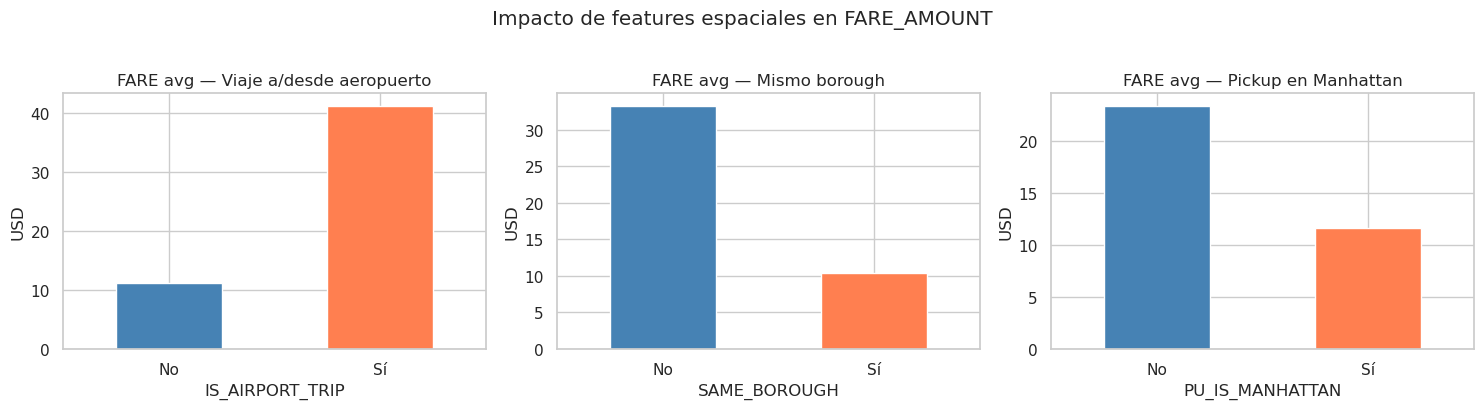

In [13]:
# Visualizar impacto de features espaciales en el target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label in zip(
    axes,
    ['IS_AIRPORT_TRIP', 'SAME_BOROUGH', 'PU_IS_MANHATTAN'],
    ['Viaje a/desde aeropuerto', 'Mismo borough', 'Pickup en Manhattan']
):
    df.groupby(col)['FARE_AMOUNT'].mean().plot(
        kind='bar', ax=ax, color=['steelblue', 'coral'], rot=0
    )
    ax.set_title(f'FARE avg — {label}')
    ax.set_ylabel('USD')
    ax.set_xticklabels(['No', 'Sí'])

plt.suptitle('Impacto de features espaciales en FARE_AMOUNT', y=1.02)
plt.tight_layout()
plt.show()


## 4. Features de INTERACCIÓN

Combinaciones que capturan patrones que los modelos lineales no detectan solos.

In [14]:
# 4.1 Rush hour + aeropuerto (tarifa pico en aeropuerto)
df['RUSH_AIRPORT'] = (df['IS_RUSH_HOUR'] & df['IS_AIRPORT_TRIP']).astype(int)

# 4.2 Noche tardía + fin de semana (patrón de salidas nocturnas)
df['LATE_NIGHT_WEEKEND'] = (df['IS_LATE_NIGHT'] & df['IS_WEEKEND']).astype(int)

# 4.3 Distancia × hora del día como proxy de congestión
# Un viaje de 2 millas en rush hour vale más que uno de 2 millas a medianoche
df['DIST_X_RUSH'] = df['TRIP_DISTANCE'] * df['IS_RUSH_HOUR']

# Validar correlación con target
interact_cols = ['RUSH_AIRPORT', 'LATE_NIGHT_WEEKEND', 'DIST_X_RUSH']
corrs = df[interact_cols + ['FARE_AMOUNT']].corr()['FARE_AMOUNT'].drop('FARE_AMOUNT')
print('Correlación de features de interacción con FARE_AMOUNT:')
print(corrs.sort_values(ascending=False).round(4).to_string())

Correlación de features de interacción con FARE_AMOUNT:
DIST_X_RUSH           0.3813
RUSH_AIRPORT          0.3291
LATE_NIGHT_WEEKEND    0.0116



## 5. Resumen: todas las features nuevas

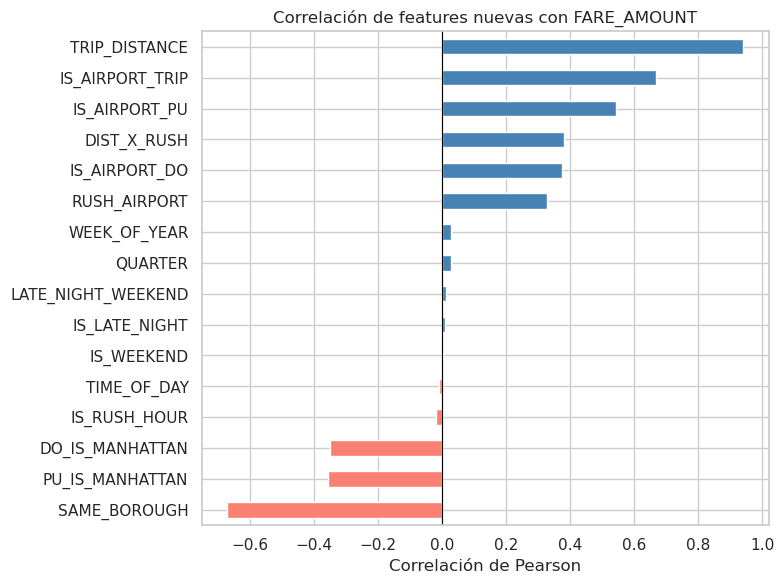

TRIP_DISTANCE         0.9402
IS_AIRPORT_TRIP       0.6676
IS_AIRPORT_PU         0.5426
DIST_X_RUSH           0.3813
IS_AIRPORT_DO         0.3750
RUSH_AIRPORT          0.3291
WEEK_OF_YEAR          0.0293
QUARTER               0.0279
LATE_NIGHT_WEEKEND    0.0116
IS_LATE_NIGHT         0.0081
IS_WEEKEND            0.0024
TIME_OF_DAY          -0.0087
IS_RUSH_HOUR         -0.0184
DO_IS_MANHATTAN      -0.3510
PU_IS_MANHATTAN      -0.3571
SAME_BOROUGH         -0.6694


In [15]:
NEW_FEATURES = [
    # Temporales
    'IS_RUSH_HOUR', 'IS_WEEKEND', 'TIME_OF_DAY',
    'WEEK_OF_YEAR', 'QUARTER', 'IS_LATE_NIGHT',
    # Espaciales
    'IS_AIRPORT_PU', 'IS_AIRPORT_DO', 'IS_AIRPORT_TRIP',
    'SAME_BOROUGH', 'PU_IS_MANHATTAN', 'DO_IS_MANHATTAN',
    # Interacción
    'RUSH_AIRPORT', 'LATE_NIGHT_WEEKEND', 'DIST_X_RUSH',
]

# Correlación de todas las features nuevas con el target
all_corr = df[NEW_FEATURES + ['FARE_AMOUNT', 'TRIP_DISTANCE']].corr()['FARE_AMOUNT']
all_corr = all_corr.drop('FARE_AMOUNT').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue' if v > 0 else 'salmon' for v in all_corr]
all_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de features nuevas con FARE_AMOUNT')
ax.set_xlabel('Correlación de Pearson')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(all_corr.round(4).to_string())


## 6. Materialización en Snowflake

Todo el cómputo de features se hace en SQL dentro de Snowflake.  
Se aplica idénticamente a `TRAIN_CLEAN`, `VAL_CLEAN` y `TEST_CLEAN`.

In [16]:
# SQL parametrizado: {SOURCE_TABLE} → {TARGET_TABLE}
# La distancia haversine usa el JOIN a TAXI_ZONES para obtener lat/lon reales

FE_SQL = """
CREATE OR REPLACE TABLE ANALYTICS.{TARGET_TABLE} AS
SELECT
    -- ── Columnas originales de la tabla limpia ─────────────────────────────
    t.*,

    -- ================================================================
    -- FEATURES TEMPORALES
    -- ================================================================

    -- Rush hour: lun-vie 7-9h y 16-19h (DAY_OF_WEEK: 2=Lun...6=Vie en Snowflake)
    CASE
        WHEN t.DAY_OF_WEEK BETWEEN 2 AND 6
         AND (t.PICKUP_HOUR BETWEEN 7 AND 9
              OR t.PICKUP_HOUR BETWEEN 16 AND 19)
        THEN 1 ELSE 0
    END AS IS_RUSH_HOUR,

    -- Fin de semana (1=Dom, 7=Sáb en Snowflake)
    CASE WHEN t.DAY_OF_WEEK IN (1, 7) THEN 1 ELSE 0 END AS IS_WEEKEND,

    -- Franja del día: 0=madrugada(0-5), 1=mañana(6-11), 2=tarde(12-17), 3=noche(18-23)
    CASE
        WHEN t.PICKUP_HOUR BETWEEN 0  AND 5  THEN 0
        WHEN t.PICKUP_HOUR BETWEEN 6  AND 11 THEN 1
        WHEN t.PICKUP_HOUR BETWEEN 12 AND 17 THEN 2
        ELSE 3
    END AS TIME_OF_DAY,

    -- Semana del año (1-53)
    WEEKOFYEAR(t.PICKUP_DATETIME) AS WEEK_OF_YEAR,

    -- Trimestre (1-4)
    QUARTER(t.PICKUP_DATETIME) AS QUARTER,

    -- Noche tardía: 22h-4h
    CASE
        WHEN t.PICKUP_HOUR >= 22 OR t.PICKUP_HOUR <= 4
        THEN 1 ELSE 0
    END AS IS_LATE_NIGHT,

    -- ================================================================
    -- FEATURES ESPACIALES
    -- ================================================================

    -- Flag aeropuerto pickup (JFK=132, LaGuardia=138, Newark=1)
    CASE WHEN t.PU_LOCATION_ID IN (1, 132, 138) THEN 1 ELSE 0 END AS IS_AIRPORT_PU,

    -- Flag aeropuerto dropoff
    CASE WHEN t.DO_LOCATION_ID IN (1, 132, 138) THEN 1 ELSE 0 END AS IS_AIRPORT_DO,

    -- Flag viaje que involucra cualquier aeropuerto
    CASE
        WHEN t.PU_LOCATION_ID IN (1, 132, 138)
          OR t.DO_LOCATION_ID IN (1, 132, 138)
        THEN 1 ELSE 0
    END AS IS_AIRPORT_TRIP,

    -- Mismo borough pickup y dropoff
    CASE WHEN t.PU_BOROUGH = t.DO_BOROUGH THEN 1 ELSE 0 END AS SAME_BOROUGH,

    -- Manhattan flags
    CASE WHEN t.PU_BOROUGH = 'Manhattan' THEN 1 ELSE 0 END AS PU_IS_MANHATTAN,
    CASE WHEN t.DO_BOROUGH = 'Manhattan' THEN 1 ELSE 0 END AS DO_IS_MANHATTAN,

    -- ================================================================
    -- FEATURES DE INTERACCIÓN
    -- ================================================================

    -- Rush hour + aeropuerto
    CASE
        WHEN t.DAY_OF_WEEK BETWEEN 2 AND 6
         AND (t.PICKUP_HOUR BETWEEN 7 AND 9 OR t.PICKUP_HOUR BETWEEN 16 AND 19)
         AND (t.PU_LOCATION_ID IN (1,132,138) OR t.DO_LOCATION_ID IN (1,132,138))
        THEN 1 ELSE 0
    END AS RUSH_AIRPORT,

    -- Noche tardía + fin de semana
    CASE
        WHEN (t.PICKUP_HOUR >= 22 OR t.PICKUP_HOUR <= 4)
         AND t.DAY_OF_WEEK IN (1, 7)
        THEN 1 ELSE 0
    END AS LATE_NIGHT_WEEKEND,

    -- Distancia × rush hour
    CASE
        WHEN t.DAY_OF_WEEK BETWEEN 2 AND 6
         AND (t.PICKUP_HOUR BETWEEN 7 AND 9 OR t.PICKUP_HOUR BETWEEN 16 AND 19)
        THEN t.TRIP_DISTANCE
        ELSE 0
    END AS DIST_X_RUSH

FROM ANALYTICS.{SOURCE_TABLE} t

-- JOIN al lookup de zonas para obtener coordenadas de centroides
LEFT JOIN RAW.TAXI_ZONES tz_pu ON t.PU_LOCATION_ID = tz_pu.LOCATIONID
LEFT JOIN RAW.TAXI_ZONES tz_do ON t.DO_LOCATION_ID = tz_do.LOCATIONID
;
"""

print('SQL de feature engineering definido.')
print(f'Features nuevas que se crean: {len(NEW_FEATURES)}')
print(NEW_FEATURES)

SQL de feature engineering definido.
Features nuevas que se crean: 15
['IS_RUSH_HOUR', 'IS_WEEKEND', 'TIME_OF_DAY', 'WEEK_OF_YEAR', 'QUARTER', 'IS_LATE_NIGHT', 'IS_AIRPORT_PU', 'IS_AIRPORT_DO', 'IS_AIRPORT_TRIP', 'SAME_BOROUGH', 'PU_IS_MANHATTAN', 'DO_IS_MANHATTAN', 'RUSH_AIRPORT', 'LATE_NIGHT_WEEKEND', 'DIST_X_RUSH']


In [17]:
# Aplicar TRAIN_CLEAN a TRAIN_FE
execute(
    FE_SQL.format(SOURCE_TABLE='TRAIN_CLEAN', TARGET_TABLE='TRAIN_FE'),
    label='TRAIN_FE creado'
)
df_v = query("SELECT COUNT(*) AS N FROM ANALYTICS.TRAIN_FE")
print(f'  Filas: {df_v["N"][0]:,}')

✓ TRAIN_FE creado
  Filas: 756,082,886


In [18]:
# Aplicar VAL_CLEAN a VAL_FE
execute(
    FE_SQL.format(SOURCE_TABLE='VAL_CLEAN', TARGET_TABLE='VAL_FE'),
    label='VAL_FE creado'
)
df_v = query("SELECT COUNT(*) AS N FROM ANALYTICS.VAL_FE")
print(f'  Filas: {df_v["N"][0]:,}')

✓ VAL_FE creado
  Filas: 36,092,486


In [19]:
# Aplicar TEST_CLEAN a TEST_FE
execute(
    FE_SQL.format(SOURCE_TABLE='TEST_CLEAN', TARGET_TABLE='TEST_FE'),
    label='TEST_FE creado'
)
df_v = query("SELECT COUNT(*) AS N FROM ANALYTICS.TEST_FE")
print(f'  Filas: {df_v["N"][0]:,}')

✓ TEST_FE creado
  Filas: 35,972,142


## 7. Verificación final

In [20]:
# Conteos y columnas de TRAIN_FE
df_cols = query("SELECT * FROM ANALYTICS.TRAIN_FE LIMIT 1")
print(f'Columnas totales en TRAIN_FE: {df_cols.shape[1]}')
print()
print('Nuevas features presentes:')
nuevas_presentes = [c for c in NEW_FEATURES if c.upper() in df_cols.columns.str.upper().tolist()]
print(nuevas_presentes)

Columnas totales en TRAIN_FE: 59

Nuevas features presentes:
['IS_RUSH_HOUR', 'IS_WEEKEND', 'TIME_OF_DAY', 'WEEK_OF_YEAR', 'QUARTER', 'IS_LATE_NIGHT', 'IS_AIRPORT_PU', 'IS_AIRPORT_DO', 'IS_AIRPORT_TRIP', 'SAME_BOROUGH', 'PU_IS_MANHATTAN', 'DO_IS_MANHATTAN', 'RUSH_AIRPORT', 'LATE_NIGHT_WEEKEND', 'DIST_X_RUSH']


In [22]:
# Estadísticas de las features nuevas en TRAIN_FE (sample)
df_stats = query(f"""
    SELECT
        AVG(IS_RUSH_HOUR) AS PCT_RUSH,
        AVG(IS_WEEKEND) AS PCT_WEEKEND,
        AVG(IS_AIRPORT_TRIP) AS PCT_AIRPORT,
        AVG(SAME_BOROUGH) AS PCT_SAME_BOROUGH,
        AVG(IS_LATE_NIGHT) AS PCT_LATE_NIGHT,
        AVG(FARE_AMOUNT) AS AVG_FARE
    FROM ANALYTICS.TRAIN_FE
    TABLESAMPLE (1)
""")
print('Estadísticas de TRAIN_FE (1% sample):')
print(df_stats.round(4).to_string(index=False))

Estadísticas de TRAIN_FE (1% sample):
 PCT_RUSH  PCT_WEEKEND  PCT_AIRPORT  PCT_SAME_BOROUGH  PCT_LATE_NIGHT  AVG_FARE
   0.2705       0.1282       0.0689            0.8726          0.1936   13.2858


In [24]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║         RESUMEN FEATURE ENGINEERING                              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  TEMPORALES (6 features):                                        ║
║  • IS_RUSH_HOUR    — lun-vie 7-9h y 16-19h                       ║
║  • IS_WEEKEND      — sábado o domingo                            ║
║  • TIME_OF_DAY     — franja 0-3 (madrugada/mañana/tarde/noche)   ║
║  • WEEK_OF_YEAR    — semana 1-53 (estacionalidad)                ║
║  • QUARTER         — trimestre 1-4                               ║
║  • IS_LATE_NIGHT   — 22h-4h                                      ║
║                                                                  ║
║  ESPACIALES (7 features):                                        ║
║  • IS_AIRPORT_PU   — pickup en JFK/LGA/EWR                       ║
║  • IS_AIRPORT_DO   — dropoff en JFK/LGA/EWR                      ║
║  • IS_AIRPORT_TRIP — cualquier extremo es aeropuerto             ║
║  • SAME_BOROUGH    — pickup y dropoff en mismo borough           ║
║  • PU_IS_MANHATTAN — pickup en Manhattan                         ║
║  • DO_IS_MANHATTAN — dropoff en Manhattan                        ║
║                                                                  ║
║  INTERACCIÓN (3 features):                                       ║
║  • RUSH_AIRPORT       — rush hour + aeropuerto                   ║
║  • LATE_NIGHT_WEEKEND — noche tardía + fin de semana             ║
║  • DIST_X_RUSH        — distancia × rush hour                    ║
║                                                                  ║
║  Tablas generadas: TRAIN_FE, VAL_FE, TEST_FE                     ║
║  Cómputo 100% en Snowflake (Pushdown). Sin leakage.              ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         RESUMEN FEATURE ENGINEERING                              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  TEMPORALES (6 features):                                        ║
║  • IS_RUSH_HOUR    — lun-vie 7-9h y 16-19h                       ║
║  • IS_WEEKEND      — sábado o domingo                            ║
║  • TIME_OF_DAY     — franja 0-3 (madrugada/mañana/tarde/noche)   ║
║  • WEEK_OF_YEAR    — semana 1-53 (estacionalidad)                ║
║  • QUARTER         — trimestre 1-4                               ║
║  • IS_LATE_NIGHT   — 22h-4h                                      ║
║                                                                  ║
║  ESPACIALES (7 features):                                        ║
║  • IS_AIRPORT_PU   — pickup en JFK/LGA/EWR                       ║
║  • IS_AIRPORT_DO   — dropoff en